In [20]:
# Importing Libraries
import pandas as pd
import numpy as np

In [22]:
# Loading Dataset 
df = pd.read_csv(r"C:\Users\dassh\Downloads\Branch Cash Flow Insights\Bank_Branch_Dataset.csv")
df.head(10)

,Branch_ID,Region,Date,Cash_Deposits,Cash_Withdrawals,Opening_Balance,Closing_Balance,Cash_Shortage_Flag
0,B39,East,2024-01-01,225458.0,227535.0,234012.0,231935,0
1,B29,East,2024-01-02,304466.0,335901.0,632750.0,601315,0
2,B15,West,2024-01-03,489503.0,118012.0,745974.0,1117465,0
3,B43,North,2024-01-04,136724.0,408894.0,707730.0,435560,0
4,B8,South,2024-01-05,279204.0,429187.0,232161.0,82178,1
5,B21,East,2024-01-06,146393.0,96116.0,654529.0,704806,0
6,B39,West,2024-01-07,NaN,184233.0,447066.0,702291,0
7,B19,North,2024-01-08,126312.0,72152.0,464546.0,518706,0
8,B23,West,2024-01-09,387468.0,146379.0,263190.0,504279,0
9,B11,South,2024-01-10,121196.0,266905.0,446256.0,300547,0


In [23]:
# Basic Info
df.info

<bound method DataFrame.info of      Branch_ID Region        Date  Cash_Deposits  Cash_Withdrawals  \
0          B39   East  2024-01-01       225458.0          227535.0   
1          B29   East  2024-01-02       304466.0          335901.0   
2          B15   West  2024-01-03       489503.0          118012.0   
3          B43  North  2024-01-04       136724.0          408894.0   
4           B8  South  2024-01-05       279204.0          429187.0   
...        ...    ...         ...            ...               ...   
2995       B46   East  2032-03-14       201770.0          200974.0   
2996        B4   East  2032-03-15       485686.0          421785.0   
2997       B45   West  2032-03-16            NaN          272366.0   
2998       B20   East  2032-03-17       497126.0          434411.0   
2999       B17  South  2032-03-18            NaN          290319.0   

      Opening_Balance  Closing_Balance  Cash_Shortage_Flag  
0            234012.0           231935                   0  
1    

In [24]:
# Data Cleaning 
# Check Nulls
df.isnull().sum()

Branch_ID               0
Region                  0
Date                    0
Cash_Deposits         150
Cash_Withdrawals      150
Opening_Balance       150
Closing_Balance         0
Cash_Shortage_Flag      0
dtype: int64

In [25]:
# Fill Null Values With Median
df.fillna({
    "Cash_Deposits": df["Cash_Deposits"].median(),
    "Cash_Withdrawals": df["Cash_Withdrawals"].median(),
    "Opening_Balance": df["Opening_Balance"].median()
}, inplace=True)

,Branch_ID,Region,Date,Cash_Deposits,Cash_Withdrawals,Opening_Balance,Closing_Balance,Cash_Shortage_Flag
0,B39,East,2024-01-01,225458.0,227535.0,234012.0,231935,0
1,B29,East,2024-01-02,304466.0,335901.0,632750.0,601315,0
2,B15,West,2024-01-03,489503.0,118012.0,745974.0,1117465,0
3,B43,North,2024-01-04,136724.0,408894.0,707730.0,435560,0
4,B8,South,2024-01-05,279204.0,429187.0,232161.0,82178,1
...,...,...,...,...,...,...,...,...
2995,B46,East,2032-03-14,201770.0,200974.0,767191.0,767987,0
2996,B4,East,2032-03-15,485686.0,421785.0,307042.0,370943,0
2997,B45,West,2032-03-16,282160.5,272366.0,381644.0,473082,0
2998,B20,East,2032-03-17,497126.0,434411.0,694897.0,757612,0


In [26]:
# Recalculate closing balance after cleaning
df["Closing_Balance"] = df["Opening_Balance"] + df["Cash_Deposits"] - df["Cash_Withdrawals"]


In [14]:
# Convert date
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
# Exploratory Data Analysis
import matplotlib.pyplot as plt

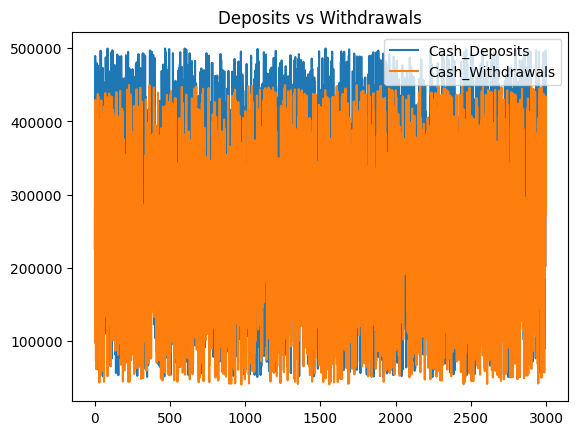

In [27]:
# Deposits vs Withdrawals
df[["Cash_Deposits","Cash_Withdrawals"]].plot()
plt.title("Deposits vs Withdrawals")
plt.show()

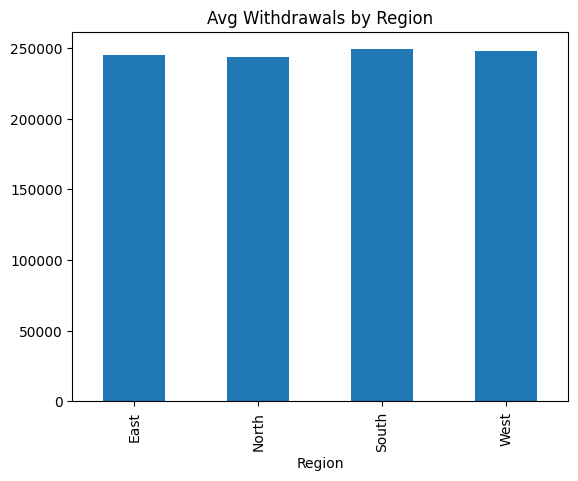

In [28]:
# Region-wise withdrawals
df.groupby("Region")["Cash_Withdrawals"].mean().plot(kind="bar")
plt.title("Avg Withdrawals by Region")
plt.show()

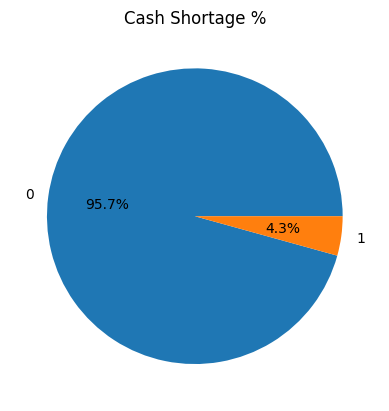

In [29]:
# Shortage distribution
df["Cash_Shortage_Flag"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Cash Shortage %")
plt.show()

In [19]:
# Connecting Python Script to PostgreSQL

from sqlalchemy import create_engine
from urllib.parse import quote_plus

# DB credentials
username = "postgres"
password = quote_plus("Shiva@2001")
host = "localhost"
port = "5432"
database = "ATM_Cash_Optimization"

# Create connection
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Load to PostgreSQL
table_name = "bank_data"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'bank_data' in database 'ATM_Cash_Optimization'.
